# Disease Outcome Classifier
## Predicting Diabetes Outcomes from Clinical Data
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Dataset:** Pima Indians Diabetes Database (768 patients, 8 clinical features)  
**Goal:** Build and compare ML models to predict diabetes diagnosis from patient data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 1: Exploratory Data Analysis
Check for missing values, class balance, and feature distributions.

In [2]:
# Basic info
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['Outcome'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (768, 9)

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 2: Data Cleaning
Several columns contain 0 values that are biologically impossible (e.g. Glucose=0, BMI=0). These are actually missing values encoded as 0. We replace them with the column median to preserve distribution.

In [3]:
# Replace impossible 0s with NaN, then fill with median
zero_not_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_not_valid:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("Zero values remaining:")
print((df[zero_not_valid] == 0).sum())
df.describe()

Zero values remaining:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 3: Visualizations
Exploring feature distributions and correlations before modeling.

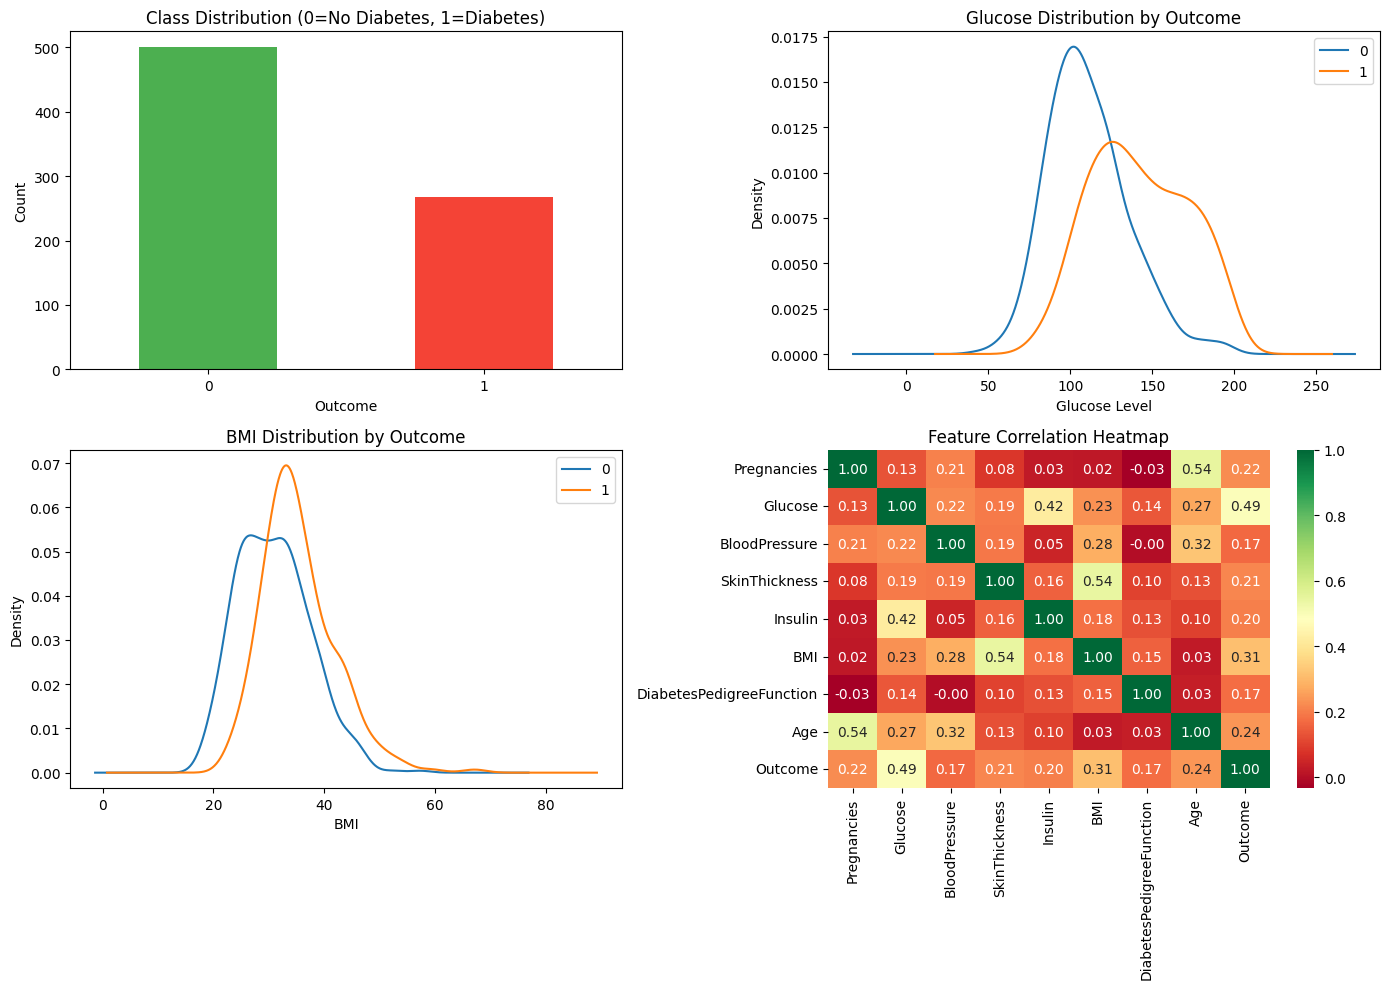

Saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#4CAF50','#F44336'])
axes[0,0].set_title('Class Distribution (0=No Diabetes, 1=Diabetes)')
axes[0,0].set_xlabel('Outcome')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(rotation=0)

# 2. Glucose distribution by outcome
df.groupby('Outcome')['Glucose'].plot(kind='kde', ax=axes[0,1], legend=True)
axes[0,1].set_title('Glucose Distribution by Outcome')
axes[0,1].set_xlabel('Glucose Level')

# 3. BMI distribution by outcome
df.groupby('Outcome')['BMI'].plot(kind='kde', ax=axes[1,0], legend=True)
axes[1,0].set_title('BMI Distribution by Outcome')
axes[1,0].set_xlabel('BMI')

# 4. Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

## Step 4: Model Building
Splitting data, scaling features, and training three models for comparison.

In [5]:
# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    }
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))


Logistic Regression:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154


Decision Tree:
              precision    recall  f1-score   support

           0       0.78      0.77      0.78        99
           1       0.60      0.62      0.61        55

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154


Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0

## Step 5: Model Comparison & Feature Importance
Comparing all three models visually and identifying which clinical features drive predictions.

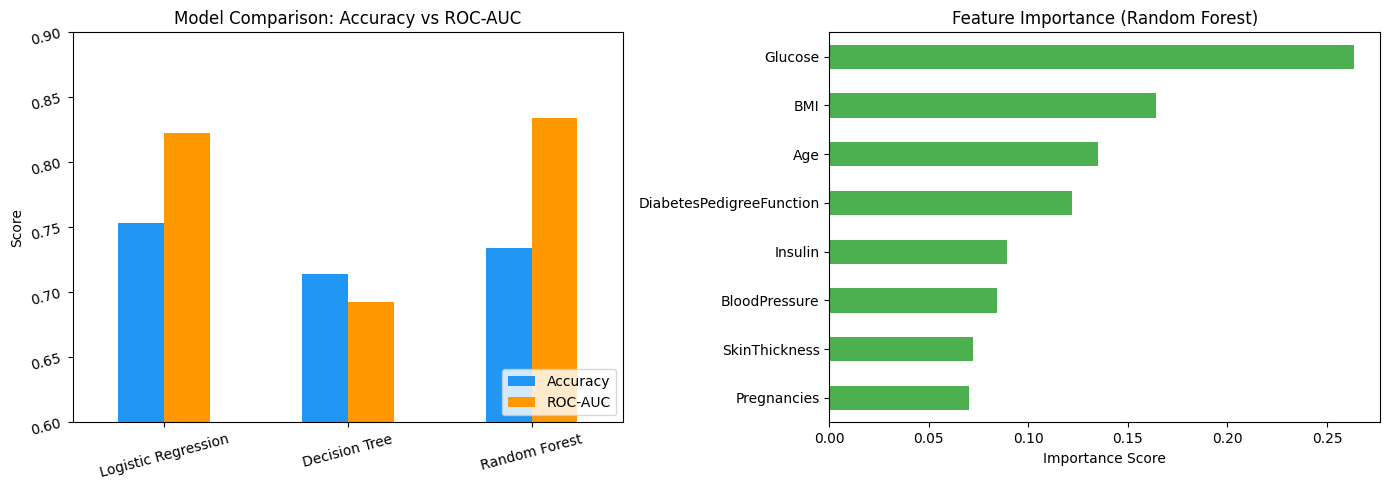

Saved!


In [6]:
# Model comparison bar chart
results_df = pd.DataFrame(results).T
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(kind='bar', ax=axes[0], color=['#2196F3', '#FF9800'])
axes[0].set_title('Model Comparison: Accuracy vs ROC-AUC')
axes[0].set_ylabel('Score')
axes[0].tick_params(rotation=15)
axes[0].set_ylim(0.6, 0.9)
axes[0].legend(loc='lower right')

# Feature importance from Random Forest
feat_importance = pd.Series(
    models['Random Forest'].feature_importances_,
    index=X.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', ax=axes[1], color='#4CAF50')
axes[1].set_title('Feature Importance (Random Forest)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

## Step 6: Confusion Matrix & Model Export
Visualizing prediction errors and saving the best model for deployment.

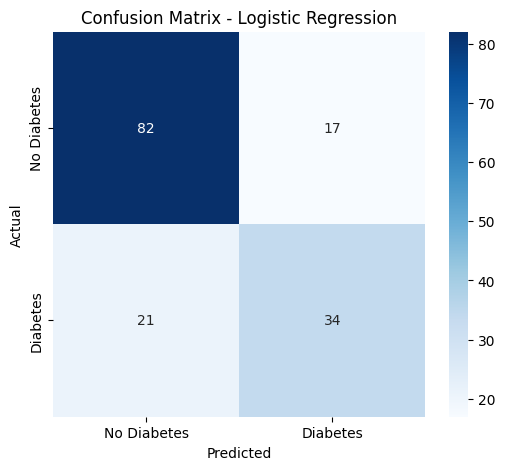

Model saved as diabetes_classifier.pkl
Scaler saved as scaler.pkl


In [7]:
# Confusion matrix for best model (Logistic Regression)
best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the model
joblib.dump(best_model, 'diabetes_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved as diabetes_classifier.pkl")
print("Scaler saved as scaler.pkl")

## Summary & Key Findings

- **Best Model:** Logistic Regression (75% accuracy, 0.82 ROC-AUC)
- **Most Important Feature:** Glucose level — consistent with clinical diabetes diagnosis criteria
- **Key Insight:** 21 false negatives in a healthcare context is meaningful — future work could optimize for recall to reduce missed diagnoses
- **Model saved** as `diabetes_classifier.pkl` for deployment

**Tools used:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Joblib

## Step 7: Hyperparameter Tuning with GridSearchCV
Me being extra. Testing multiple parameter combinations to find the optimal Random Forest configuration.

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", round(grid_search.best_score_, 4))

# Compare with original
y_pred_tuned = grid_search.best_estimator_.predict(X_test_scaled)
print("\nTuned Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Tuned ROC-AUC:", round(roc_auc_score(y_test, grid_search.best_estimator_.predict_proba(X_test_scaled)[:,1]), 4))

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best ROC-AUC Score: 0.8434

Tuned Random Forest Accuracy: 0.7597
Tuned ROC-AUC: 0.8362


## Step 8: ROC Curve
Visualizing the tradeoff between true positive rate and false positive rate across all three models.

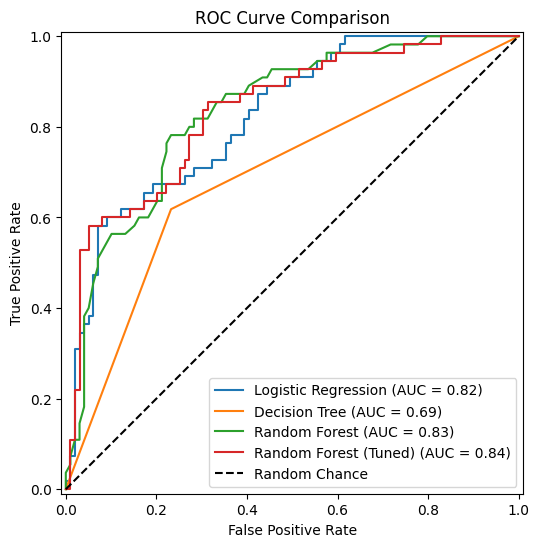

Saved!


In [9]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)

# Add tuned Random Forest
RocCurveDisplay.from_estimator(grid_search.best_estimator_, X_test_scaled, y_test, ax=ax, name='Random Forest (Tuned)')

ax.plot([0,1], [0,1], 'k--', label='Random Chance')
ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')

plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

## Step 9: Production Pipeline
Wrapping the best model into a sklearn Pipeline for clean, deployable inference.

In [10]:
from sklearn.pipeline import Pipeline

# Build production pipeline
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        max_depth=5,
        min_samples_split=5,
        n_estimators=200,
        random_state=42
    ))
])

best_pipeline.fit(X_train, y_train)
pipeline_preds = best_pipeline.predict(X_test)
pipeline_auc = roc_auc_score(y_test, best_pipeline.predict_proba(X_test)[:,1])

print("Pipeline Accuracy:", round(accuracy_score(y_test, pipeline_preds), 4))
print("Pipeline ROC-AUC:", round(pipeline_auc, 4))

# Save the full pipeline
joblib.dump(best_pipeline, 'diabetes_pipeline.pkl')
print("\nProduction pipeline saved as diabetes_pipeline.pkl")
print("To use: pipeline.predict(new_patient_data)")

Pipeline Accuracy: 0.7597
Pipeline ROC-AUC: 0.8362

Production pipeline saved as diabetes_pipeline.pkl
To use: pipeline.predict(new_patient_data)
